# Vehicle Tracking Analysis

This notebook systematically evaluates vehicle tracking models across day and night conditions, and demonstrates real-world performance on day/night transitions.

## Workflow
1. Setup & Imports
2. Define Zones (detection areas)
3. Compare models/trackers on DAY video
4. Compare models/trackers on NIGHT video
5. Run on 10 minute day/night transition video
6. Demo: Live Deployment
7. Explainable AI: Understanding Model Predictions

---
# 1. Setup & Imports
---

### 1.1 Mount Drive (Colab only)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not in Colab. Running locally.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1.2 Install & Import Libraries

In [2]:
# Auto-install if needed
%pip install -U ultralytics opencv-python-headless --quiet

import torch
import os
from pathlib import Path

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU")

GPU: Tesla T4
VRAM: 15.6 GB


### 1.3 Project Setup & Load Custom Modules

In [3]:
import importlib
import os
import sys
from pathlib import Path

# Resolve project root for Colab/local runs
if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/SVV/Master_Thesis/Model")
else:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent / "Model"]
    PROJECT_ROOT = next(
        (p for p in candidates if (p / "src").exists()),
        Path("/Users/sondre/Library/CloudStorage/GoogleDrive-haugen.sondre@gmail.com/Min disk/SVV/Master_Thesis/Model"),
    )

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

os.chdir(PROJECT_ROOT)

from src import GT as GT_mod
from src import evaluation, explainable_ai as xai_mod, run_video_deploy as run_video_deploy_mod, tracking_utils

for module in (evaluation, tracking_utils, GT_mod, xai_mod, run_video_deploy_mod):
    importlib.reload(module)

from src.GT import CLASS_ORDER, FLOW_ORDER, load_gt_persons, load_gt_vehicles
from src.evaluation import display_model_results, plot_class_distribution_detailed, run_experiments
from src.run_video_deploy import run_video_deploy
from src.tracking_utils import display_lines_on_frame, setup_tracking_context

print(f"Setup complete: {PROJECT_ROOT}")

Setup complete: /content/drive/MyDrive/SVV/Master_Thesis/Model


---
# 2. Define Zones
---

Define detection zones (gate zones) where vehicles are counted and classified.

In [4]:
GATE_ZONES = {
    "S": {"polygon": [(35, 255), (360, 255), (280, 450), (0, 450)], "dir": "S", "type": "vehicle"},
    "N": {"polygon": [(355, 155), (430, 125), (370, 250), (185, 245)], "dir": "N", "type": "vehicle"},
    "E": {"polygon": [(400, 200), (790, 200), (790, 305), (360, 325)], "dir": "E", "type": "vehicle"},
    "Gangfeltet": {"polygon": [(250, 165), (250, 200), (420, 195), (420, 175)], "dir": "Gangfeltet", "type": "person"},
}

print(f"Defined {len(GATE_ZONES)} zones: {list(GATE_ZONES.keys())}")

Defined 4 zones: ['S', 'N', 'E', 'Gangfeltet']


### 2.1 Visualize Zones on Sample Frame

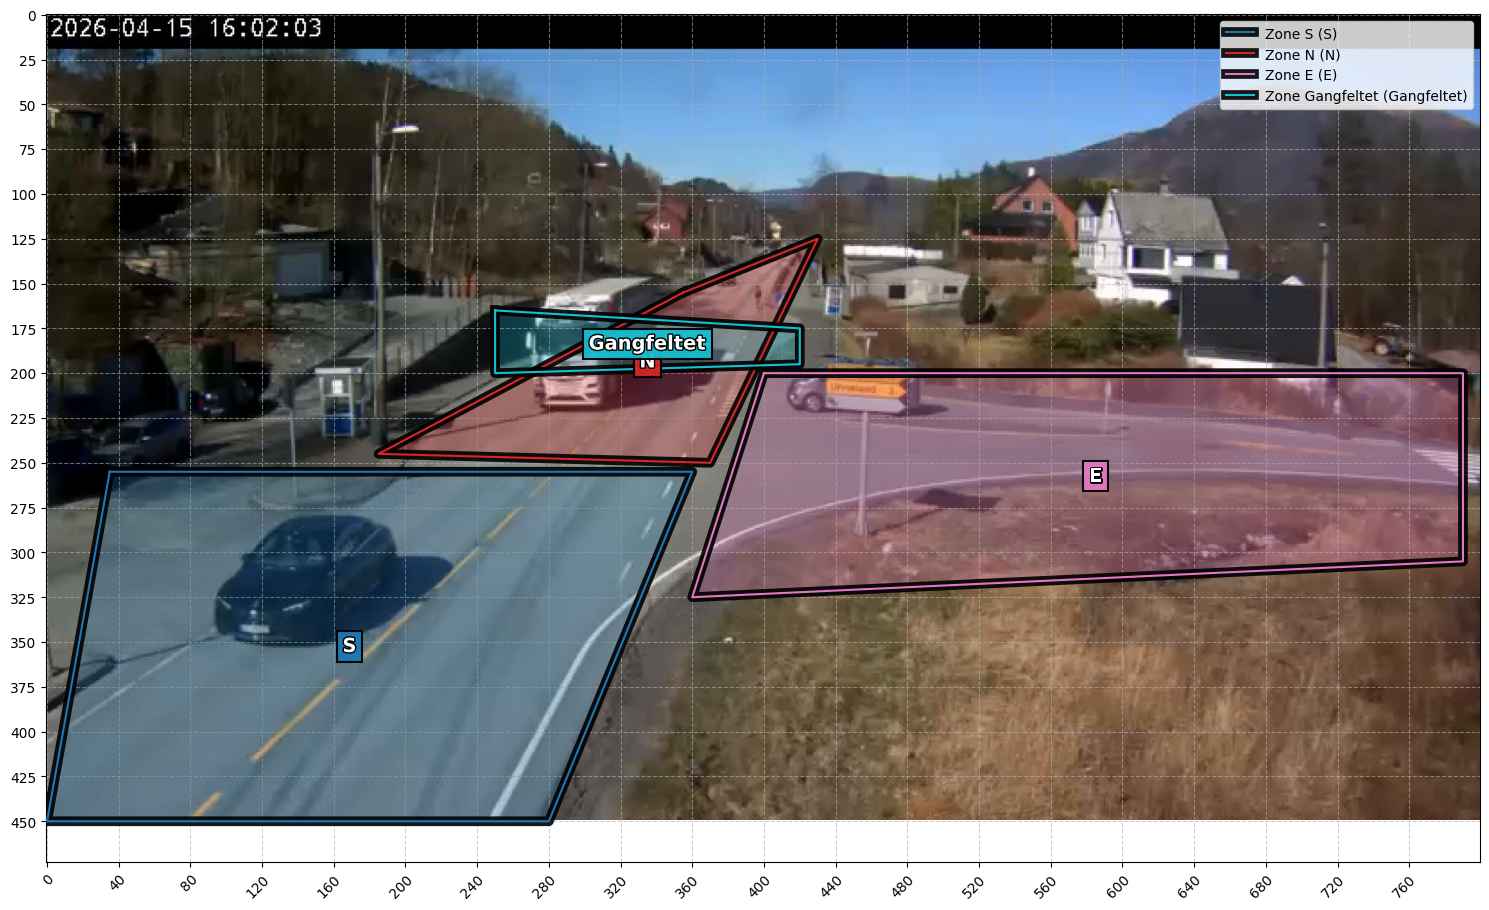

{}

In [5]:
# Visualize zones on a sample video
cfg_sample = setup_tracking_context(
    video_name="Fv587_Haukeland_day_diff_10min.mp4",
    drive_base=PROJECT_ROOT,
    apply_globals=False
)
display_lines_on_frame(cfg_sample["video_source"], arm_zones=GATE_ZONES)

---
# 3. Compare Models & Trackers on DAY Video
---

## 3.1 Comparing models & trackers on 15 minute day video

### 3.1.1 Configuration for 15 minute Day Video

In [6]:
# 15 minute day video configuration
VIDEO_DAY = "Fv587_Haukeland_15min.mp4"

# Models to test
MODELS_DAY = [
    "YOLO26n_final.pt",
    "YOLO26m_final.pt",
]
# Trackers to test
TRACKERS_DAY = {
    "bytetrack": "bytetrack.yaml",
    "botsort": "botsort.yaml",
    "day_botsort": "day_botsort.yaml",
}

# Load ground truth for day video - VEHICLES
gt_dict_day_vehicles, gt_df_day = load_gt_vehicles(VIDEO_DAY)

# Load ground truth for day video - PERSONS
gt_gangfeltet_day, gt_persons_day = load_gt_persons(VIDEO_DAY)

### 3.1.2 Run 15 minute Day

In [7]:
# Run DAY experiments using the generic function
all_results_day, all_pred_tables_day, all_diff_tables_day, summary_df_day, persons_df_day = run_experiments(
    models=MODELS_DAY,
    trackers=TRACKERS_DAY,
    video_name=VIDEO_DAY,
    gt_df=gt_df_day,
    gt_persons=gt_persons_day,
    session_label="DAY",
    video_type="day",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
    max_frames=10,  # Limit to first 4500 frames for faster testing
)

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_day)

Running DAY video experiments with run_video_deploy...


DAY | YOLO26n_final.pt | bytetrack
Day-tracker only: bytetrack.yaml

  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_15min_132914.mp4
Duration: 1.1s | FPS: 8.8
Frames: 10 | Day: 0 | Night: 0
Mode switches: 0
Detections: 45 | Stable tracks: 5
Counted trips: 0
Fallback recovery: same_id=0, split_id=0

Complete

DAY | YOLO26n_final.pt | botsort
Day-tracker only: botsort.yaml

  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_15min_132915.mp4
Duration: 0.5s | FPS: 22.0
Frames: 10 | Day: 0 | Night: 0
Mode switches: 0
Detections: 45 | Stable tracks: 5
Counted trips: 0
Fallback recovery: same_id=0, split_id=0

Complete

DAY | YOLO26n_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Ma

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26n_final.pt,botsort,39.666667,5.666667,100.0,0.453535
1,YOLO26m_final.pt,bytetrack,39.666667,5.666667,100.0,0.582839
2,YOLO26m_final.pt,botsort,39.666667,5.666667,100.0,0.591222
3,YOLO26n_final.pt,day_botsort,39.666667,5.666667,100.0,0.670060
4,YOLO26m_final.pt,day_botsort,39.666667,5.666667,100.0,0.971570
5,YOLO26n_final.pt,bytetrack,39.666667,5.666667,100.0,1.139096



DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,3,0,-3,100.0
1,YOLO26n_final.pt,botsort,3,0,-3,100.0
2,YOLO26n_final.pt,day_botsort,3,0,-3,100.0
3,YOLO26m_final.pt,bytetrack,3,0,-3,100.0
4,YOLO26m_final.pt,botsort,3,0,-3,100.0
5,YOLO26m_final.pt,day_botsort,3,0,-3,100.0


In [103]:
# Run DAY experiments using the generic function
all_results_day, all_pred_tables_day, all_diff_tables_day, summary_df_day, persons_df_day = run_experiments(
    models=MODELS_DAY,
    trackers=TRACKERS_DAY,
    video_name=VIDEO_DAY,
    gt_df=gt_df_day,
    gt_persons=gt_persons_day,
    session_label="DAY",
    video_type="day",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
)

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_day)

Running DAY video experiments with run_video_deploy...


DAY | YOLO26n_final.pt | bytetrack
Day-tracker only: bytetrack.yaml
  18000/18066 | 67.6 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 267.4s | FPS: 67.6
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41714 | Stable tracks: 352
Counted trips: 239
Fallback recovery: same_id=2, split_id=1

Complete

DAY | YOLO26n_final.pt | botsort
Day-tracker only: botsort.yaml
  18000/18066 | 38.0 FPS
  Finalizing remaining tracks...
  Finalized 2 remaining tracks

Tracking Complete
Output: None
Duration: 476.0s | FPS: 38.0
Frames: 18066 | Day: 0 | Night: 0
Mode switches: 0
Detections: 41855 | Stable tracks: 284
Counted trips: 239
Fallback recovery: same_id=1, split_id=1

Complete

DAY | YOLO26n_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.1

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,day_botsort,0.000000,0.047619,0.000000,487.899825
1,YOLO26m_final.pt,bytetrack,0.000000,0.142857,0.000000,359.813047
2,YOLO26m_final.pt,botsort,0.000000,0.142857,0.000000,531.643617
3,YOLO26n_final.pt,bytetrack,0.500000,0.166667,0.420168,267.417501
4,YOLO26n_final.pt,botsort,0.500000,0.214286,0.420168,476.028497
5,YOLO26n_final.pt,day_botsort,0.833333,0.309524,2.100840,416.139076



DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,3,0,-3,100.000000
1,YOLO26n_final.pt,botsort,3,0,-3,100.000000
2,YOLO26n_final.pt,day_botsort,3,0,-3,100.000000
3,YOLO26m_final.pt,bytetrack,3,5,2,66.666667
4,YOLO26m_final.pt,botsort,3,5,2,66.666667
5,YOLO26m_final.pt,day_botsort,3,3,0,0.000000


### 3.1.3 Visualizations of 15 minute video

In [123]:
# Use the built-in display_model_results function for detailed analysis
display_model_results(
    gt_df=gt_df_day,
    all_pred_tables=all_pred_tables_day,
    all_diff_tables=all_diff_tables_day,
    summary_df=summary_df_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
)


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,134,5,2,1,0,1,0,143
N->S,71,4,4,1,1,3,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



  MODEL: YOLO26m_final.pt  |  TRACKER: botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,133,6,2,1,0,1,0,143
N->S,72,3,4,2,1,2,0,84
E->S,1,0,0,0,0,0,0,1
E->N,1,0,0,0,0,0,0,1
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



--- DIFF TABLE (pred - gt) ---


...


  sum_mae=0.50  |  cell_mae=0.17  |  total_pred=239  |  total_gt=238  |  total_err=1  |  total_abs_pct_err=0.4%  |  perfect_routes=3

  MODEL: YOLO26n_final.pt  |  TRACKER: day_botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,139,4,2,1,0,1,0,147
N->S,72,3,3,3,1,2,0,84
E->S,1,0,0,0,0,0,0,1
E->N,2,0,0,0,0,0,0,2
S->E,4,0,0,0,0,1,0,5
N->E,4,0,0,0,0,0,0,4



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,5,-1,0,0,0,0,0,4
N->S,1,-1,-1,2,0,-1,0,0
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,0,0,0,0,0,0,0,0
N->E,0,0,0,0,0,0,0,0



  sum_mae=0.83  |  cell_mae=0.31  |  total_pred=243  |  total_gt=238  |  total_err=5  |  total_abs_pct_err=2.1%  |  perfect_routes=3



DAY - CLASS COMPOSITION & DISTRIBUTION


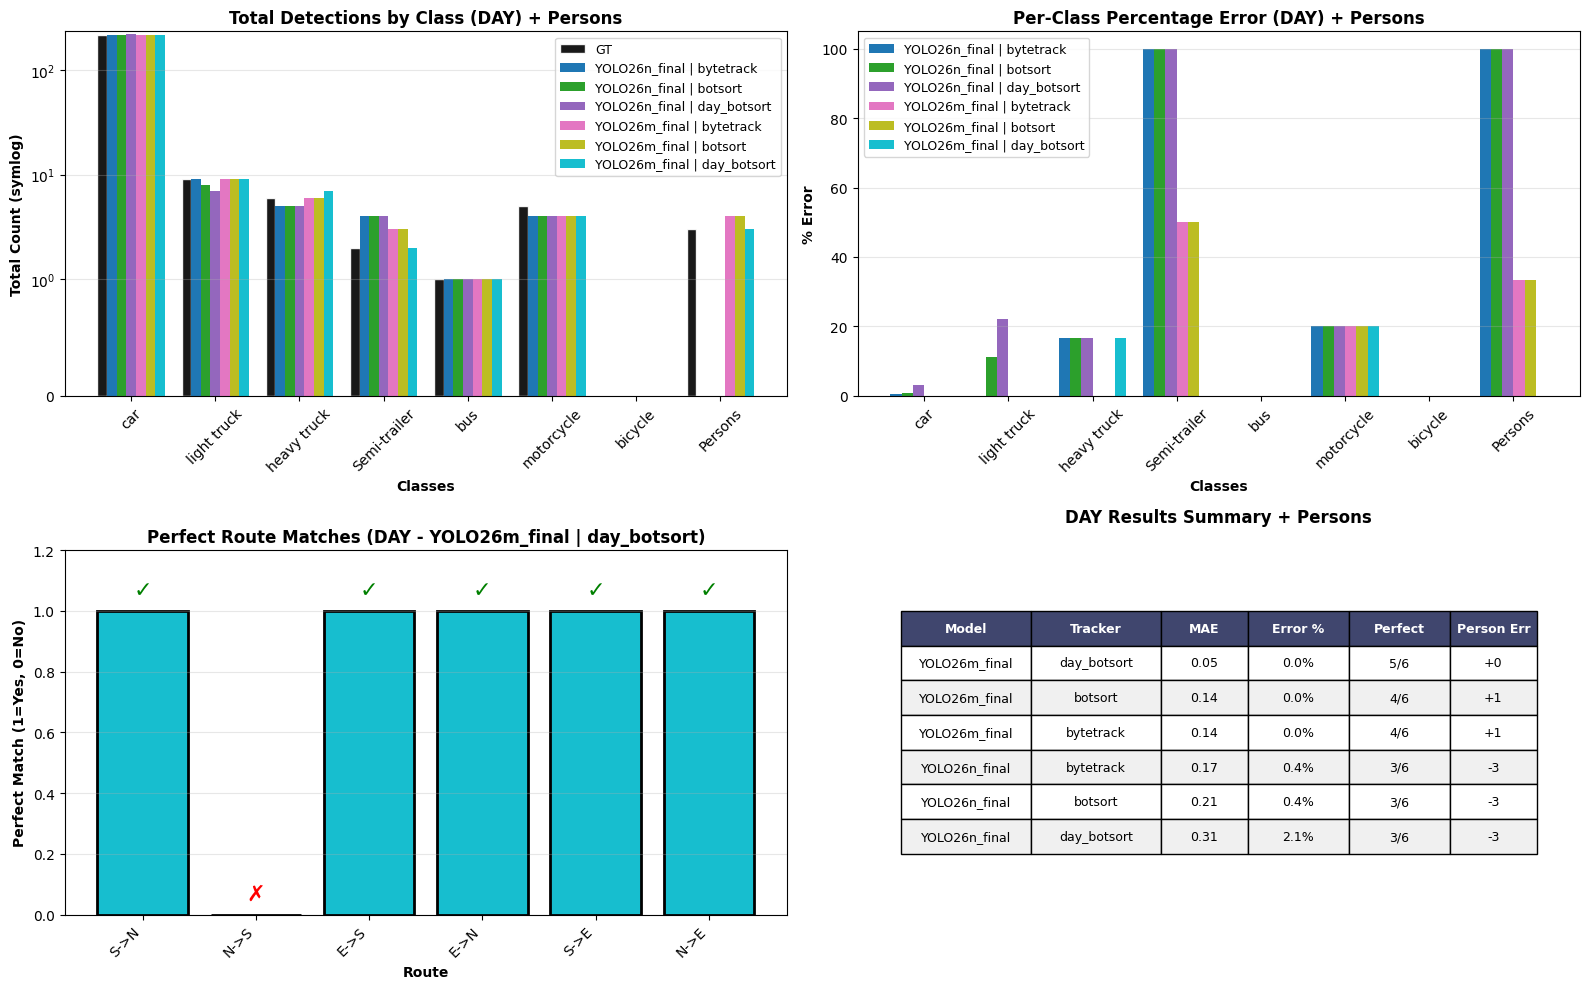


Class composition analysis complete


In [117]:
# Plot class distribution with detailed breakdown for the 15 minute day video
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_day,
    all_diff_tables=all_diff_tables_day,
    gt_df=gt_df_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="DAY",
    all_results=all_results_day,
    gt_persons=gt_persons_day,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

## 3.2 Test the best model and tracker on 1 hour rush video 

### 3.2.1 Set up and run the best model/tracker on 1 hour video

In [188]:
# 1 hour day video
VIDEO_FULL = "Fv587_Haukeland_day_1h_rush.mp4"

# best model/tracker from 15 min day video experiments
MODELS_1H_DAY = ["YOLO26m_final.pt"]
TRACKERS_1H_DAY = {
    "day_botsort": "day_botsort.yaml",
}
# Load ground truth for 1 hour day video - VEHICLES
gt_dict_1h_day, gt_df_1h_day = load_gt_vehicles(VIDEO_FULL)

# Load ground truth for 1 hour day video - PERSONS (Gangfeltet)
gt_gangfeltet_1h_day, gt_persons_1h_day = load_gt_persons(VIDEO_FULL)

# Run 1h day 
all_results_1h_day, all_pred_tables_1h_day, all_diff_tables_1h_day, summary_df_1h_day, persons_df_1h_day = run_experiments(
    models=MODELS_1H_DAY,
    trackers=TRACKERS_1H_DAY,
    video_name=VIDEO_FULL,
    gt_df=gt_df_1h_day,
    gt_persons=gt_persons_1h_day,
    session_label="1h DAY",
    video_type="day",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    gate_zones=GATE_ZONES,
)

results_1h_day = all_results_1h_day[(MODELS_1H_DAY[0], "day_botsort")]
display(summary_df_1h_day[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("1h DAY RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_1h_day)

Running 1h DAY video experiments with run_video_deploy...


1h DAY | YOLO26m_final.pt | day_botsort
Day-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
  71800/71899 | 32.0 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_day_1h_rush_125014.mp4
Duration: 2249.8s | FPS: 32.0
Frames: 71899 | Day: 0 | Night: 0
Mode switches: 0
Detections: 178747 | Stable tracks: 1281
Counted trips: 1080
Person counts by zone: {'Gangfeltet': 6}
Fallback recovery: same_id=2, split_id=19

Complete

1h DAY RESULTS SUMMARY - VEHICLES


,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,day_botsort,1.666667,0.666667,0.94162,2249.794215



1h DAY RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26m_final.pt,day_botsort,7,6,-1,14.285714


### 3.2.2 Ground Truth matrix comparison

In [189]:
# Then display again
display_model_results(
    gt_df=gt_df_1h_day,
    all_pred_tables=all_pred_tables_1h_day,
    all_diff_tables=all_diff_tables_1h_day,
    summary_df=summary_df_1h_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
)


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,523,16,14,15,3,17,1,589
N->S,354,11,11,14,2,13,2,407
E->S,18,0,0,0,0,0,0,18
E->N,16,0,0,0,0,0,1,17
S->E,14,0,0,0,0,1,3,18
N->E,10,1,0,0,2,0,0,13



  MODEL: YOLO26m_final.pt  |  TRACKER: day_botsort

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,529,19,11,14,3,17,1,594
N->S,352,11,11,15,3,14,2,408
E->S,18,0,0,0,0,0,0,18
E->N,16,1,0,0,0,0,0,17
S->E,18,0,0,0,0,3,1,22
N->E,10,1,0,0,2,0,0,13



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,6,3,-3,-1,0,0,0,5
N->S,-2,0,0,1,1,1,0,1
E->S,0,0,0,0,0,0,0,0
E->N,0,1,0,0,0,0,-1,0
S->E,4,0,0,0,0,2,-2,4
N->E,0,0,0,0,0,0,0,0



  sum_mae=1.67  |  cell_mae=0.67  |  total_pred=1072  |  total_gt=1062  |  total_err=10  |  total_abs_pct_err=0.9%  |  perfect_routes=2


### 3.2.3 Class distribution and perfect routes


DAY - CLASS COMPOSITION & DISTRIBUTION


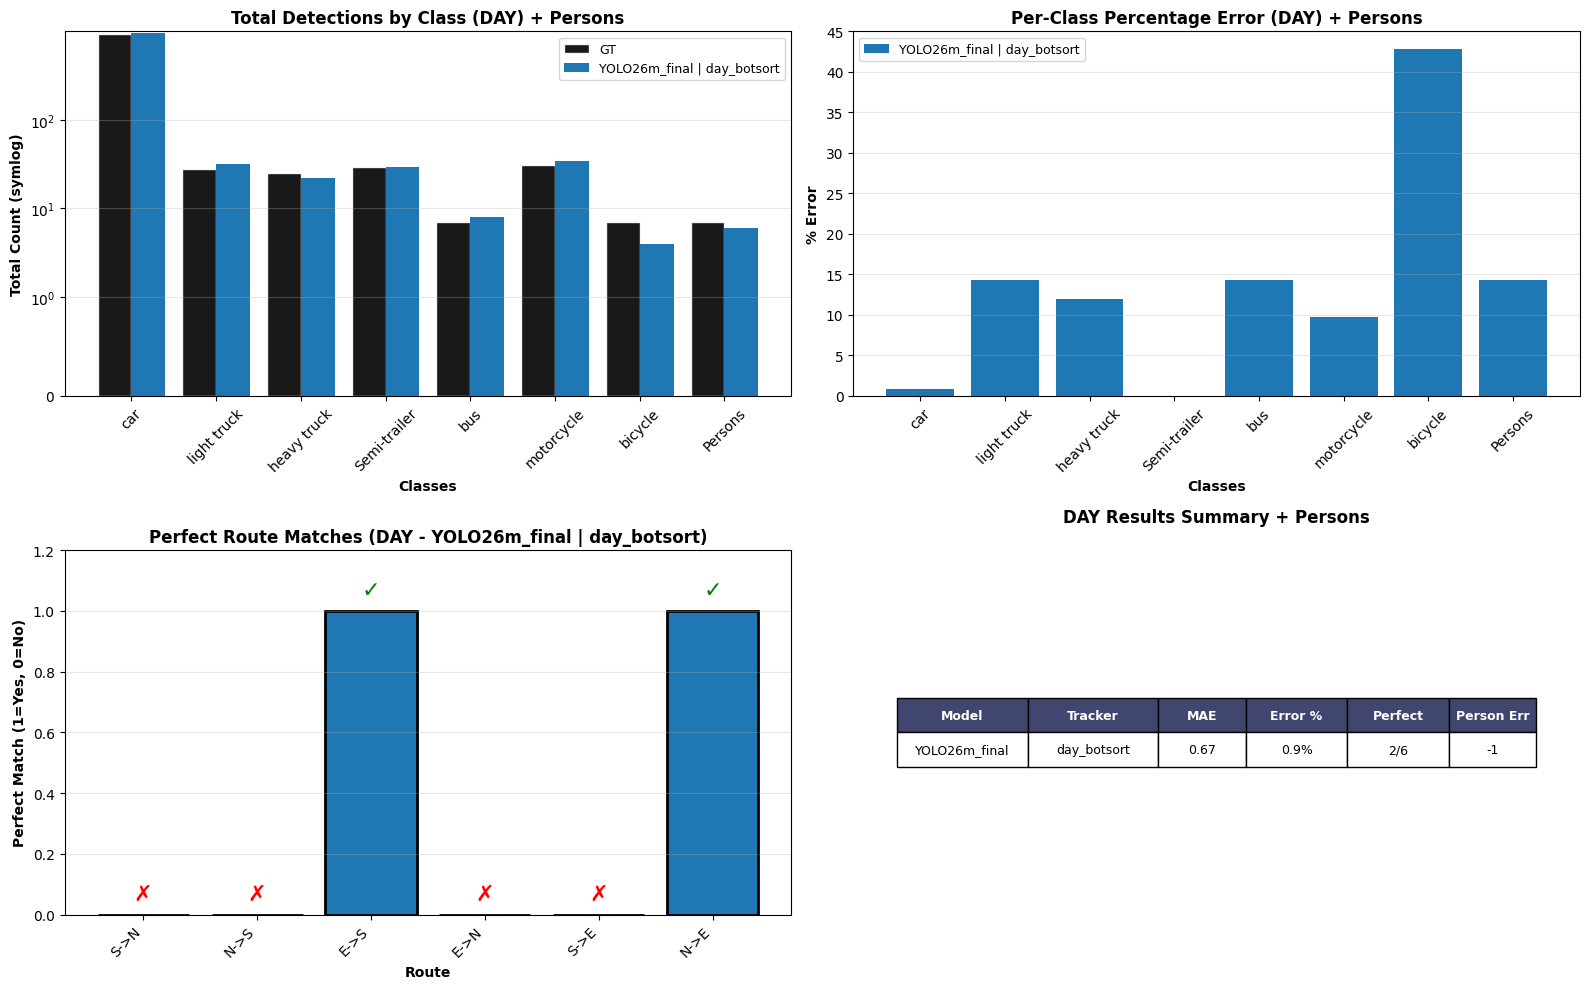


Class composition analysis complete


In [190]:
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_1h_day,
    all_diff_tables=all_diff_tables_1h_day,
    gt_df=gt_df_1h_day,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="DAY",
    all_results=all_results_1h_day,
    gt_persons=gt_persons_1h_day,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

---
# 4. Compare Models & Trackers on 1 hour NIGHT Video
---

### 4.1 NIGHT Video Configuration

In [8]:
# 1 hour night video configuration
VIDEO_NIGHT = "Fv587_Haukeland_night_1h.mp4"

# Models to test
MODELS_NIGHT = [
    "YOLO26n_final.pt",
    "YOLO26m_final.pt",
]
# Trackers to test
TRACKERS_NIGHT = {
    "bytetrack": "bytetrack.yaml",
    #"night_botsort": "night_botsort.yaml",
    "night_botsort_conservative": "night_botsort_conservative.yaml",
}

# Load ground truth for night video - VEHICLES
gt_dict_night_vehicles, gt_df_night = load_gt_vehicles(VIDEO_NIGHT)

# Load ground truth for night video - PERSONS (Gangfeltet)
gt_gangfeltet_night, gt_persons_night = load_gt_persons(VIDEO_NIGHT)

### 4.2 Run NIGHT Experiments

In [9]:
# Run NIGHT experiments using the generic function
all_results_night, all_pred_tables_night, all_diff_tables_night, summary_df_night, persons_df_night = run_experiments(
    models=MODELS_NIGHT,
    trackers=TRACKERS_NIGHT,
    video_name=VIDEO_NIGHT,
    gt_df=gt_df_night,
    gt_persons=gt_persons_night,
    session_label="NIGHT",
    video_type="night",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
    max_frames=100,  # Limit to first 4500 frames for faster testing
)

print("\n" + "="*80)
print("NIGHT RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_night[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("NIGHT RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_night)

Running NIGHT video experiments with run_video_deploy...


NIGHT | YOLO26n_final.pt | bytetrack
Night-tracker only: bytetrack.yaml
  100/24991 | 48.8 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_night_1h_125915.mp4
Duration: 2.1s | FPS: 48.6
Frames: 100 | Day: 0 | Night: 0
Mode switches: 0
Detections: 0 | Stable tracks: 0
Counted trips: 0
Fallback recovery: same_id=0, split_id=0

Complete

NIGHT | YOLO26n_final.pt | night_botsort_conservative
Night-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/night_botsort_conservative.yaml
  100/24991 | 45.3 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_night_1h_125917.mp4
Duration: 2.2s | FPS: 45.2
Frames: 100 | Day: 0 | Night: 0
Mode switches: 0
Detections: 0 | Stable tracks: 0
Counted

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26n_final.pt,bytetrack,22.0,3.142857,100.0,2.055625
1,YOLO26n_final.pt,night_botsort_conservative,22.0,3.142857,100.0,2.213255
2,YOLO26m_final.pt,night_botsort_conservative,22.0,3.142857,100.0,2.387356
3,YOLO26m_final.pt,bytetrack,22.0,3.142857,100.0,2.507587



NIGHT RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,0,0,0,NaN
1,YOLO26n_final.pt,night_botsort_conservative,0,0,0,NaN
2,YOLO26m_final.pt,bytetrack,0,0,0,NaN
3,YOLO26m_final.pt,night_botsort_conservative,0,0,0,NaN


In [8]:
# Run NIGHT experiments using the generic function
all_results_night, all_pred_tables_night, all_diff_tables_night, summary_df_night, persons_df_night = run_experiments(
    models=MODELS_NIGHT,
    trackers=TRACKERS_NIGHT,
    video_name=VIDEO_NIGHT,
    gt_df=gt_df_night,
    gt_persons=gt_persons_night,
    session_label="NIGHT",
    video_type="night",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
)

print("\n" + "="*80)
print("NIGHT RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_night[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("NIGHT RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_night)

Running NIGHT video experiments with run_video_deploy...


NIGHT | YOLO26n_final.pt | bytetrack
Night-tracker only: bytetrack.yaml
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 286ms
Prepared 1 package in 83ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  24900/24991 | 57.3 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_night_1h_101822.mp4
Duration: 436.0s | FPS: 57.3
Frames: 24991 | Day: 0 | Night: 0
Mode switches: 0
Detections: 4538 | Stable tracks: 189
Counted trips: 129
Fallback recovery: same_id=10, split_id=2

Complete

NIGHT | YOLO26n_final.pt | night_botsort
Night-tracker only: /content/drive/MyDrive/SVV/Master_Thesis/Model/n

,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,night_botsort_conservative,0.666667,0.285714,0.000000,584.553221
1,YOLO26m_final.pt,bytetrack,1.166667,0.309524,2.272727,621.325630
2,YOLO26m_final.pt,night_botsort,1.166667,0.357143,2.272727,594.251678
3,YOLO26n_final.pt,night_botsort_conservative,1.500000,0.357143,0.757576,480.212465
4,YOLO26n_final.pt,bytetrack,1.833333,0.404762,2.272727,436.038817
5,YOLO26n_final.pt,night_botsort,1.833333,0.404762,2.272727,462.719448



NIGHT RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26n_final.pt,bytetrack,0,0,0,NaN
1,YOLO26n_final.pt,night_botsort,0,0,0,NaN
2,YOLO26n_final.pt,night_botsort_conservative,0,0,0,NaN
3,YOLO26m_final.pt,bytetrack,0,0,0,NaN
4,YOLO26m_final.pt,night_botsort,0,0,0,NaN
5,YOLO26m_final.pt,night_botsort_conservative,0,0,0,NaN



### 4.3 NIGHT Results Visualization

In [9]:
# Use the built-in display_model_results function for detailed analysis
display_model_results(
    gt_df=gt_df_night,
    all_pred_tables=all_pred_tables_night,
    all_diff_tables=all_diff_tables_night,
    summary_df=summary_df_night,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
)


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,60,0,1,4,1,0,0,66
N->S,54,1,2,0,1,2,0,60
E->S,2,0,0,0,0,0,0,2
E->N,2,0,0,0,0,0,0,2
S->E,2,0,0,0,0,0,0,2
N->E,0,0,0,0,0,0,0,0



  MODEL: YOLO26m_final.pt  |  TRACKER: bytetrack

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,60,0,4,3,1,0,0,68
N->S,51,1,0,2,1,0,0,55
E->S,2,0,0,0,0,0,0,2
E->N,2,0,0,0,0,0,0,2
S->E,2,0,0,0,0,0,0,2
N->E,0,0,0,0,0,0,0,0



--- DIFF TABLE (pred - gt) ---


...


  sum_mae=1.83  |  cell_mae=0.40  |  total_pred=129  |  total_gt=132  |  total_err=-3  |  total_abs_pct_err=2.3%  |  perfect_routes=3

  MODEL: YOLO26n_final.pt  |  TRACKER: night_botsort_conservative

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,60,0,0,7,1,0,0,68
N->S,52,0,0,2,1,0,0,55
E->S,2,0,0,0,0,0,0,2
E->N,4,0,0,0,0,0,0,4
S->E,2,0,0,0,0,0,0,2
N->E,0,0,0,0,0,0,0,0



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,0,0,-1,3,0,0,0,2
N->S,-2,-1,-2,2,0,-2,0,-5
E->S,0,0,0,0,0,0,0,0
E->N,2,0,0,0,0,0,0,2
S->E,0,0,0,0,0,0,0,0
N->E,0,0,0,0,0,0,0,0



  sum_mae=1.50  |  cell_mae=0.36  |  total_pred=131  |  total_gt=132  |  total_err=-1  |  total_abs_pct_err=0.8%  |  perfect_routes=3



NIGHT - CLASS COMPOSITION & DISTRIBUTION


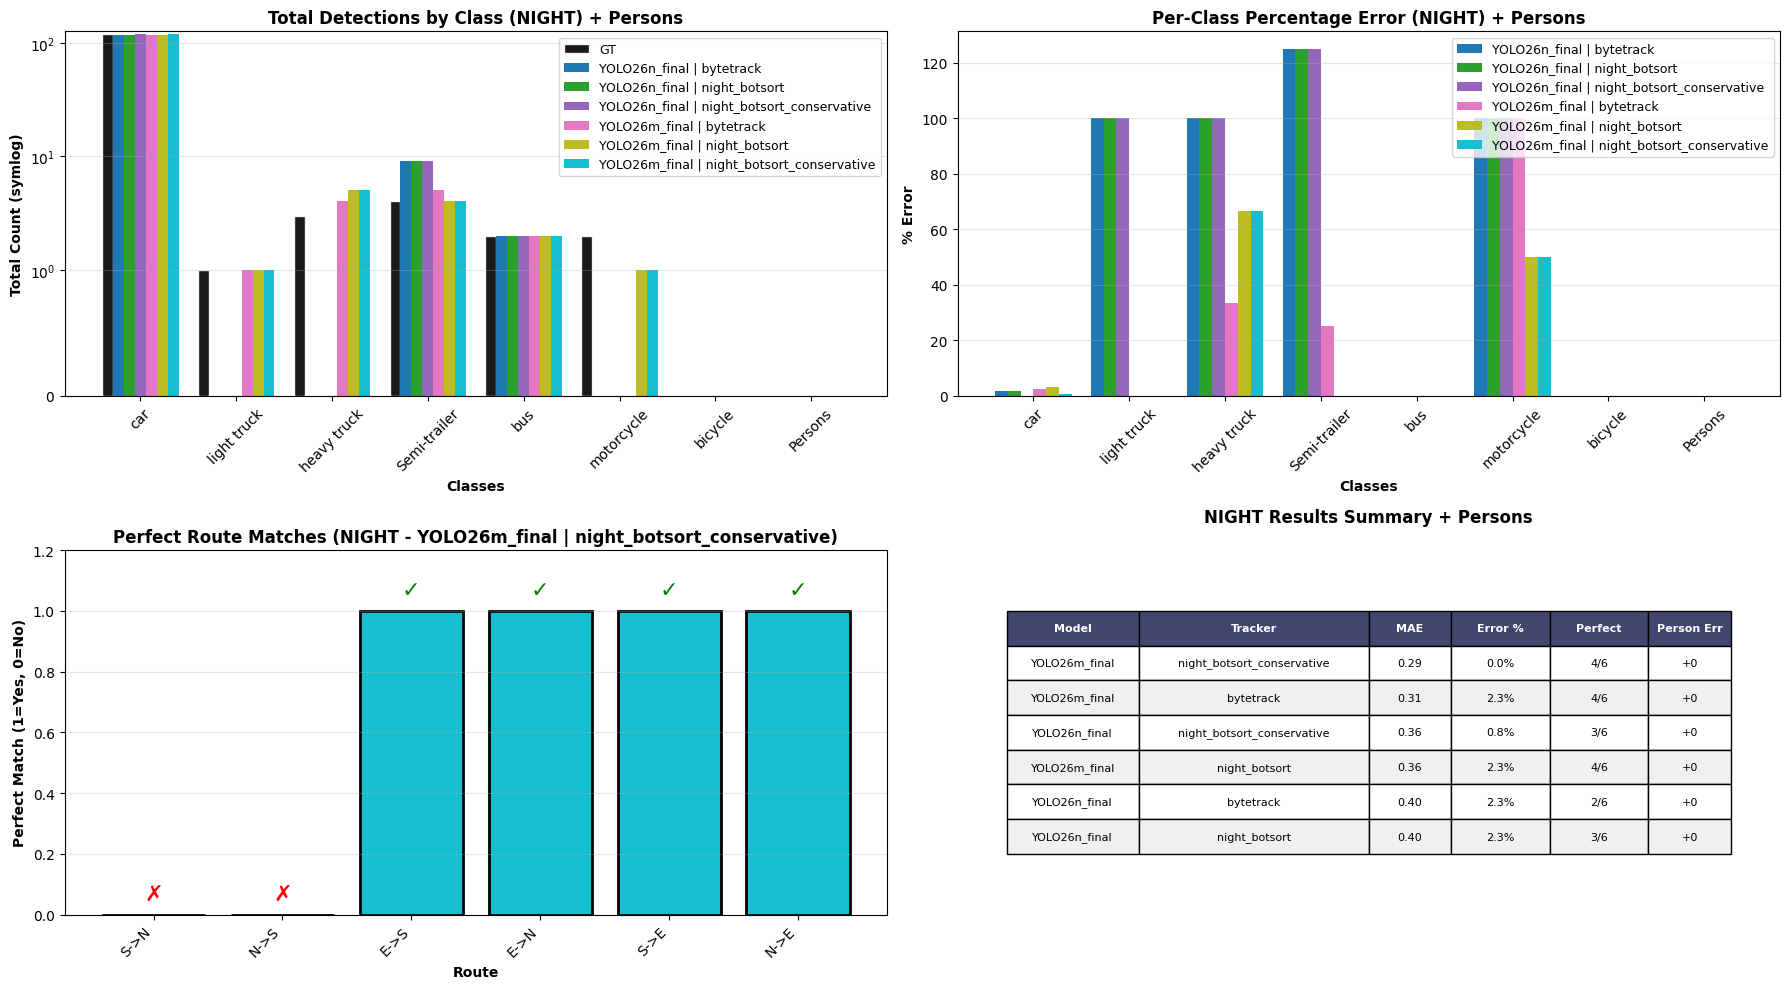


Class composition analysis complete


In [14]:
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_night,
    all_diff_tables=all_diff_tables_night,
    gt_df=gt_df_night,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="NIGHT",
    all_results=all_results_night,
    gt_persons=gt_persons_night,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

---
# 5. Run on 10 minute day/night transition video
---

### 5.1 Configuration for transition video

In [10]:
# 10 minute transition video configuration
VIDEO_TRANSITION = "Fv587_Haukeland_10min_transition.mp4"

# Best model/tracker setup (single best pair)
BEST_MODEL = ["YOLO26m_final.pt"]

# Convenience vars reused in run cell
best_day_tracker_yaml = "day_botsort.yaml"
best_night_tracker_yaml = "night_botsort_conservative.yaml"

# Load GT once

gt_dict_transition, gt_df_transition = load_gt_vehicles(VIDEO_TRANSITION)
gt_gangfeltet_transition, gt_persons_transition = load_gt_persons(VIDEO_TRANSITION)

### 5.2 Run transition Video

In [11]:
# Run transition experiments (reuse config from previous cell)
all_results_transition, all_pred_tables_transition, all_diff_tables_transition, summary_df_transition, persons_df_transition = run_experiments(
    models=BEST_MODEL,
    trackers={
        "transition_best": {
            "day": best_day_tracker_yaml,
            "night": best_night_tracker_yaml,
        }
    },
    video_name=VIDEO_TRANSITION,
    gt_df=gt_df_transition,
    gt_persons=gt_persons_transition,
    session_label="TRANSITION",
    video_type="transition",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
    max_frames=100,  # Limit to first 4500 frames for faster testing
)

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_transition[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_transition)

Running TRANSITION video experiments with run_video_deploy...


TRANSITION | YOLO26m_final.pt | transition_best
Dual-tracker mode: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml (day) ↔ /content/drive/MyDrive/SVV/Master_Thesis/Model/night_botsort_conservative.yaml (night)
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
  100/11793 | 24.0 FPS
  Finalizing remaining tracks...
  Finalized 1 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_10min_transition_125937.mp4
Duration: 4.2s | FPS: 24.0
Frames: 100 | Day: 100 | Night: 0
Mode switches: 0
Detections: 108 | Stable tracks: 2
Counted trips: 1
Fallback recovery: same_id=0, split_id=0

Complete

TRANSITION RESULTS SUMMARY - VEHICLES

TRANSITION RESULTS SUMMARY - VEHICLES


,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,transition_best,4.833333,0.690476,96.666667,4.173626



TRANSITION RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26m_final.pt,transition_best,0,0,0,NaN


In [74]:
# Run transition experiments (reuse config from previous cell)
all_results_transition, all_pred_tables_transition, all_diff_tables_transition, summary_df_transition, persons_df_transition = run_experiments(
    models=BEST_MODEL,
    trackers={
        "transition_best": {
            "day": best_day_tracker_yaml,
            "night": best_night_tracker_yaml,
        }
    },
    video_name=VIDEO_TRANSITION,
    gt_df=gt_df_transition,
    gt_persons=gt_persons_transition,
    session_label="TRANSITION",
    video_type="transition",
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    setup_tracking_context=setup_tracking_context,
    run_video_deploy=run_video_deploy,
    min_track_frames=2,
    gate_zones=GATE_ZONES,
)

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - VEHICLES")
print("="*80)
display(summary_df_transition[["model", "tracker", "sum_mae", "cell_mae", "total_abs_pct_err", "elapsed_s"]])

print("\n" + "="*80)
print("TRANSITION RESULTS SUMMARY - PERSONS")
print("="*80)
display(persons_df_transition)

Running TRANSITION video experiments with run_video_deploy...


TRANSITION | YOLO26m_final.pt | transition_best
Dual-tracker mode: /content/drive/MyDrive/SVV/Master_Thesis/Model/day_botsort.yaml (day) ↔ /content/drive/MyDrive/SVV/Master_Thesis/Model/night_botsort_conservative.yaml (night)
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
  6000/11793 | 36.5 FPS
 TRACKER SWITCH at frame 6045: NIGHT (sat=8.3, lum=85.3)
  11700/11793 | 37.5 FPS
  Finalizing remaining tracks...
  Finalized 0 remaining tracks

Tracking Complete
Output: /content/drive/MyDrive/SVV/Master_Thesis/Model/runs/instance/Fv587_Haukeland_10min_transition_121309.mp4
Duration: 314.3s | FPS: 37.5
Frames: 11793 | Day: 6044 | Night: 5749
Mode switches: 1
Detections: 5627 | Stable tracks: 65
Counted trips: 30
Fallback recovery: same_id=1, split_id=0

Complete

TRANSITION RESULTS SUMMARY - VEHICLES

TRANSITION RESULTS SUMMARY - VEHICLES


,model,tracker,sum_mae,cell_mae,total_abs_pct_err,elapsed_s
0,YOLO26m_final.pt,transition_best,0.0,0.0,0.0,314.316957



TRANSITION RESULTS SUMMARY - PERSONS


,model,tracker,gt_persons,predicted_persons,error,pct_error
0,YOLO26m_final.pt,transition_best,0,0,0,NaN


### 5.3 Ground Truth matrix comparison

In [75]:
# Use the built-in display_model_results function for detailed analysis
display_model_results(
    gt_df=gt_df_transition,
    all_pred_tables=all_pred_tables_transition,
    all_diff_tables=all_diff_tables_transition,
    summary_df=summary_df_transition,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
)


=== GROUND TRUTH ===


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,16,0,0,0,0,0,0,16
N->S,10,0,0,0,1,0,1,12
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,1,0,0,0,0,0,0,1
N->E,0,0,0,0,0,0,0,0



  MODEL: YOLO26m_final.pt  |  TRACKER: transition_best

--- PREDICTION TABLE ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,16,0,0,0,0,0,0,16
N->S,10,0,0,0,1,0,1,12
E->S,0,0,0,0,0,0,0,0
E->N,1,0,0,0,0,0,0,1
S->E,1,0,0,0,0,0,0,1
N->E,0,0,0,0,0,0,0,0



--- DIFF TABLE (pred - gt) ---


,car,light truck,heavy truck,semi-trailer / combination vehicle,bus,motorcycle,bicycle,Sum
S->N,0,0,0,0,0,0,0,0
N->S,0,0,0,0,0,0,0,0
E->S,0,0,0,0,0,0,0,0
E->N,0,0,0,0,0,0,0,0
S->E,0,0,0,0,0,0,0,0
N->E,0,0,0,0,0,0,0,0



  sum_mae=0.00  |  cell_mae=0.00  |  total_pred=30  |  total_gt=30  |  total_err=0  |  total_abs_pct_err=0.0%  |  perfect_routes=6


### 5.4 Class composition


TRANSITION - CLASS COMPOSITION & DISTRIBUTION


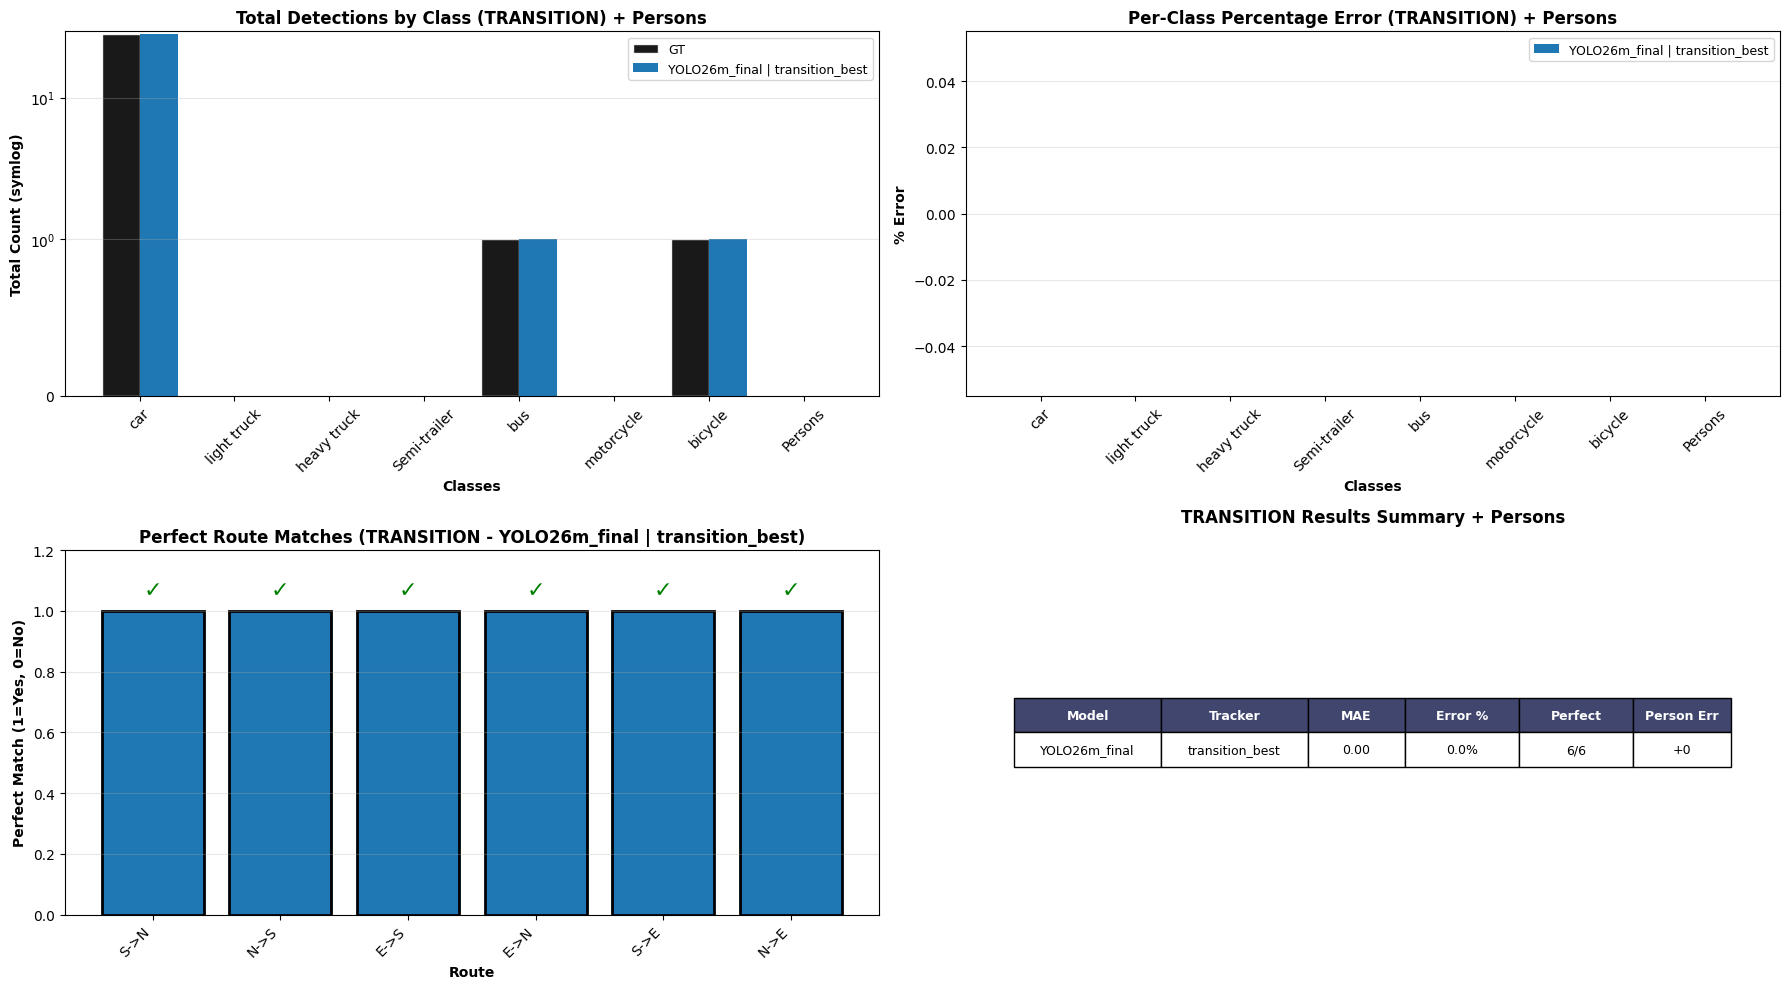


Class composition analysis complete


In [76]:
plot_class_distribution_detailed(
    all_pred_tables=all_pred_tables_transition,
    all_diff_tables=all_diff_tables_transition,
    gt_df=gt_df_transition,
    flow_order=FLOW_ORDER,
    class_order=CLASS_ORDER,
    video_type="TRANSITION",
    all_results=all_results_transition,
    gt_persons=gt_persons_transition,
    person_label="Persons",
    person_zone_name="Gangfeltet",
)

---
## 6. Demo: Live Deployment
---

---
## 7. Explainable AI: Understanding Model Predictions
---

Analyze how the YOLO detection model works by visualizing detections, confidence scores, and detection density maps.
